# Demo D: 3D Shepp-Logan random sampling with discrete non-rigid motion

A respiratory-like motion field in 3D version is applied to 3D Shepp-Logan phantom. The acquisition is supposed to be per shot, and the displacement is supposed to be in the same state during each shot (for faster motion simulation; however, note that such a motion is not realistic). 



[Demo D] Loading config...
[Demo D] Initializing runtime...
[Demo D] Loading data and building operators...
[DataLoader] k-space normalized (rms), scale=7.879848e-02


EspiritCalib:   0%|          | 0/10 [00:00<?, ?it/s]

Simulating non-rigid motion fields...


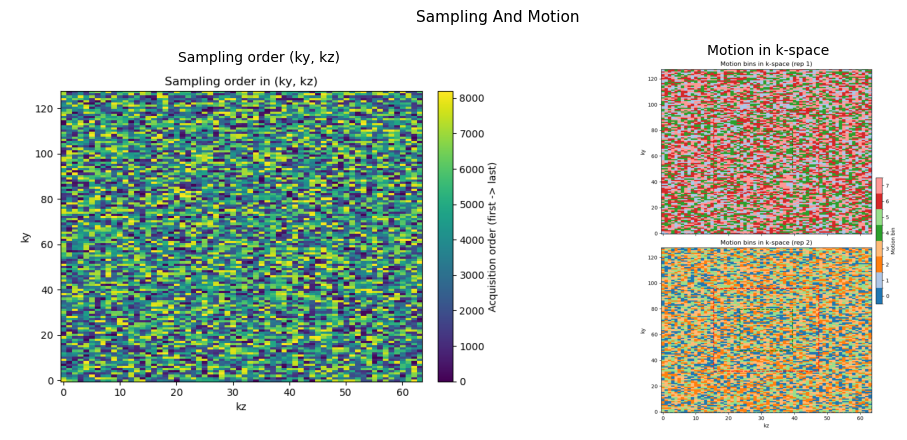

[Demo D] Starting reconstruction...


Resolution level 1/3:   0%|          | 0/10 [00:00<?, ?it/s]

Resolution level 2/3:   0%|          | 0/4 [00:00<?, ?it/s]

Resolution level 3/3:   0%|          | 0/4 [00:00<?, ?it/s]

Elapsed time: 23.34 s


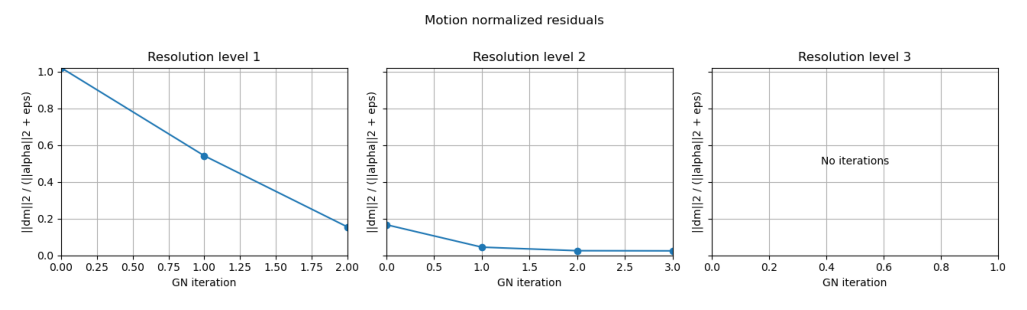

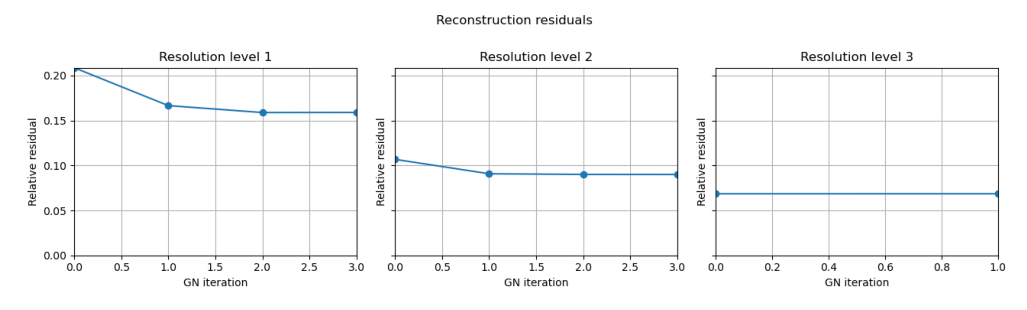

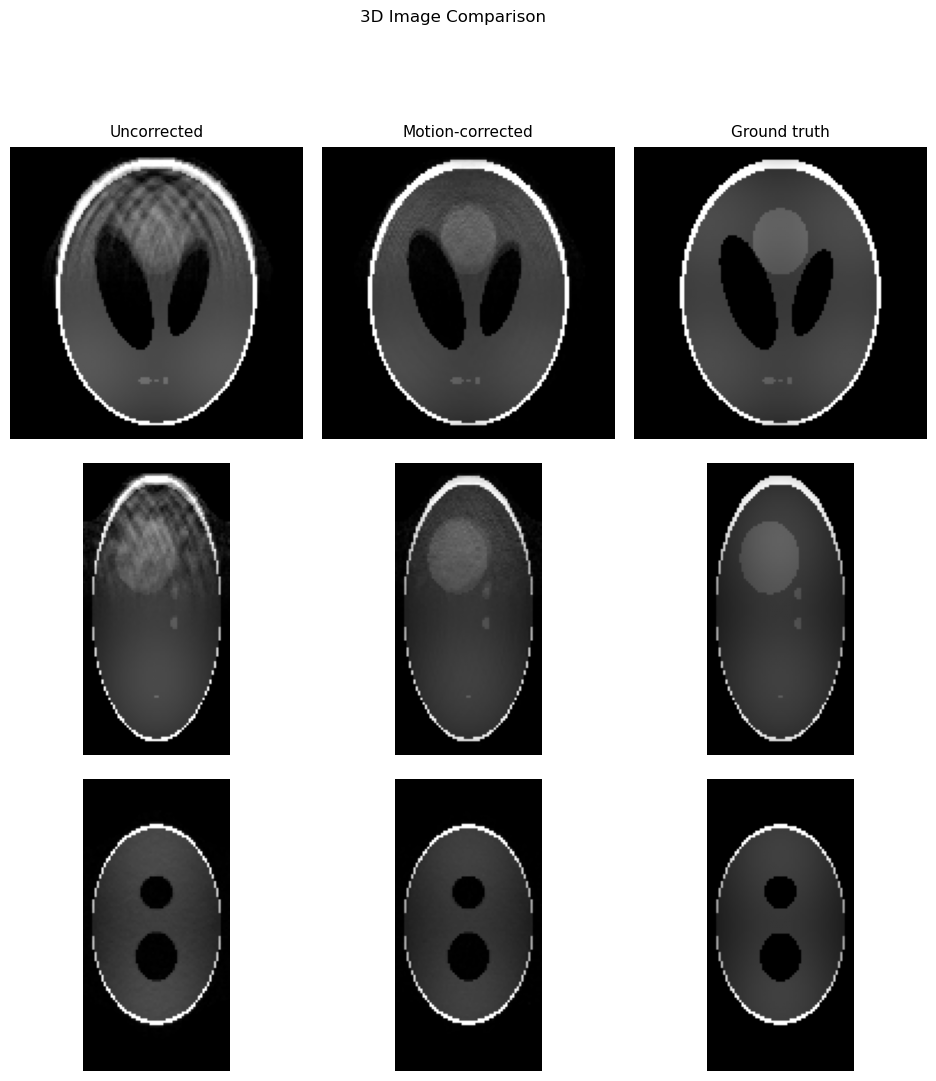

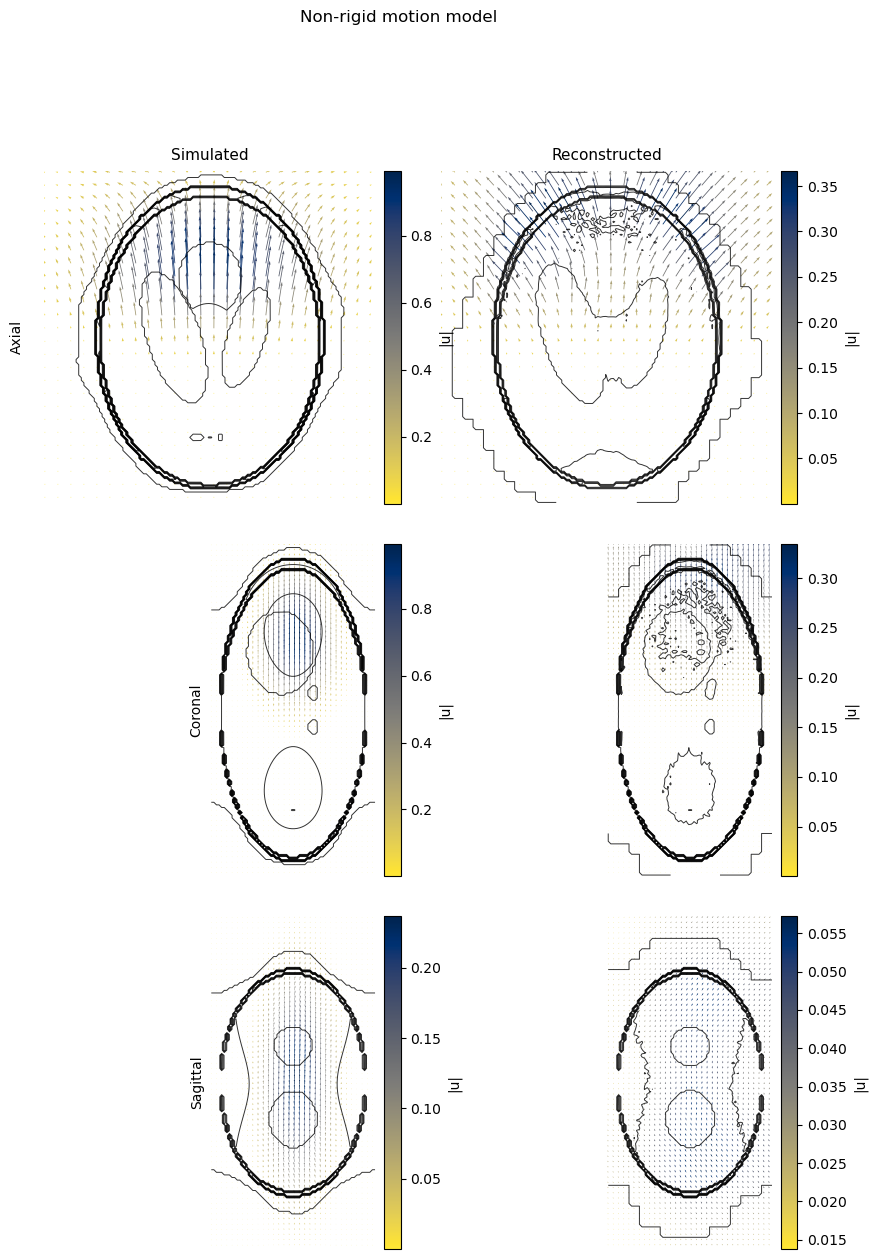

In [1]:
import time
from src.runtime.runtime_config import load_config
from src.preprocessing.DataLoader import DataLoader
from src.reconstruction.JointReconstructor import JointReconstructor
from src.runtime.runtime_setup import initialize_runtime
from src.utils.notebook_display import (
    display_input_sampling_motion_panels,
    display_run_panels,
)

jupyter_notebook_flag = True

def main():
    print("[Demo D] Loading config...")
    params = load_config(
        data_type="shepp-logan",
        shepp_logan_config="config/shepp_logan_3d.toml",
        reconstruction_config="config/reconstruction/nonrigid_3d.toml",
        sampling_config="config/sampling_simulation/random.toml",
        motion_simulation_config="config/motion_simulation/nonrigid_3d.toml",
        motion_state_mode="per-shot",
        overrides={
            "jupyter_notebook_flag": jupyter_notebook_flag,
            "flip_for_display": True,
            "Nex": 2,
            "acs": 8,
            "kernel_width": 4,
            "espirit_max_iter": 10,
            "N_motion_states": 8,
        },
    )

    print("[Demo D] Initializing runtime...")
    sp_device, t_device = initialize_runtime(params)

    print("[Demo D] Loading data and building operators...")
    data = DataLoader(params=params, t_device=t_device, sp_device=sp_device)
    display_input_sampling_motion_panels(params)


    print("[Demo D] Starting reconstruction...")
    recon = JointReconstructor(
        data.kspace,
        data.smaps,
        data.sampling_idx,
        motion_signal=data.motion_signal,
        params=params,
        motion_plot_context=data.motion_plot_context,
    )
    t0 = time.time()
    image_joint, alpha_joint = recon.run()
    print(f"Elapsed time: {time.time() - t0:.2f} s")


    display_run_panels(
        params,
        motion_type=params.reconstruction_motion_type,
        alpha_sim=data.alpha_maps_true,
        alpha_rec=alpha_joint,
        image_sim=data.image_ground_truth[0],
        image_rec=image_joint[0],
        image_uncorrected=data.image_no_moco[0],
        image_corrected=image_joint[0],
        image_gt=data.image_ground_truth[0],
    )



if __name__ == "__main__":
    main()
